# Structural breaks, regime dummies và rolling stability

Notebook này đi thẳng vào vấn đề mà báo cáo hiện tại đã phát hiện: **có break mạnh quanh 2021-2022**.
Nếu đã thấy break mà không mô hình hóa break, phần diễn giải hệ số rất dễ bị phản biện.

Notebook bổ sung 4 việc:

1. Tạo **shock/regime dummies**.
2. So sánh baseline model với model có dummies.
3. Chạy **Chow test** tại các mốc quan trọng.
4. Vẽ **rolling coefficients** để xem hệ số có ổn định hay không.


In [2]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display, Markdown

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

OUTPUT_DIR = Path("notebook_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_PATH = Path("secondary_data_annual.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Không tìm thấy secondary_data_annual.csv")

df = pd.read_csv(DATA_PATH)
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
df = df.sort_values("Year").reset_index(drop=True)
display(df.head())


,Year,GDP_Raw,Inflation,Interest_Rate,FDI_pct_GDP,Investment_pct_GDP,Export_pct_GDP,Unemployment_Rate,Gov_Spending_pct_GDP,GDP_Growth
0,1995,20.736,NaN,NaN,8.586,27.144,32.813,1.955,8.188,9.540
1,1996,24.657,5.675,20.100,9.713,28.103,40.868,1.930,8.353,9.340
2,1997,26.844,3.210,14.417,8.270,28.300,43.103,2.870,8.131,8.152
3,1998,27.210,7.266,14.400,6.141,29.050,44.848,2.290,7.624,5.764
4,1999,28.684,4.117,12.700,4.923,27.630,49.966,2.330,6.785,4.774


## 1. Cấu hình mô hình


In [3]:

TARGET = "GDP_Growth"

# Giữ mô hình tương đối gọn để tránh over-parameterization ở mẫu annual nhỏ.
BASE_REGRESSORS = [
    "Inflation",
    "Interest_Rate",
    "FDI_pct_GDP",
    "Export_pct_GDP",
    "Unemployment_Rate",
]

# Bạn có thể thêm Gov_Spending_pct_GDP hoặc Investment_pct_GDP nếu muốn.
OPTIONAL_REGRESSORS = ["Gov_Spending_pct_GDP", "Investment_pct_GDP"]
INCLUDE_OPTIONAL = False

if INCLUDE_OPTIONAL:
    BASE_REGRESSORS = BASE_REGRESSORS + OPTIONAL_REGRESSORS

required_cols = ["Year", TARGET] + BASE_REGRESSORS
model_df = df[required_cols].dropna().copy()
display(model_df.tail())


,Year,GDP_Growth,Inflation,Interest_Rate,FDI_pct_GDP,Export_pct_GDP,Unemployment_Rate
24,2019,7.359,2.796,7.708,4.821,85.158,1.681
25,2020,2.865,3.221,7.648,4.558,84.382,2.103
26,2021,2.554,1.835,7.811,4.273,93.850,2.383
27,2022,8.538,3.157,8.013,4.329,93.420,1.570
28,2023,5.065,3.253,9.323,4.264,86.467,1.645


## 2. Tạo regime dummies


In [4]:

model_df["gfc_2008_2009"] = model_df["Year"].between(2008, 2009).astype(int)
model_df["covid_2020_2021"] = model_df["Year"].between(2020, 2021).astype(int)
model_df["tightening_2022plus"] = (model_df["Year"] >= 2022).astype(int)

# Interaction: độ nhạy của GDP growth với lãi suất có thay đổi sau 2022 hay không?
model_df["interest_x_tightening"] = model_df["Interest_Rate"] * model_df["tightening_2022plus"]

display(model_df[["Year", "gfc_2008_2009", "covid_2020_2021", "tightening_2022plus", "interest_x_tightening"]].tail(10))


,Year,gfc_2008_2009,covid_2020_2021,tightening_2022plus,interest_x_tightening
19,2014,0,0,0,0.000
20,2015,0,0,0,0.000
21,2016,0,0,0,0.000
22,2017,0,0,0,0.000
23,2018,0,0,0,0.000
24,2019,0,0,0,0.000
25,2020,0,1,0,0.000
26,2021,0,1,0,0.000
27,2022,0,0,1,8.013
28,2023,0,0,1,9.323


## 3. Hàm ước lượng baseline / augmented


In [5]:

def fit_hac_ols(frame: pd.DataFrame, y_col: str, x_cols: list[str], maxlags: int = 1):
    tmp = frame[[y_col] + x_cols].dropna().copy()
    X = sm.add_constant(tmp[x_cols])
    y = tmp[y_col]
    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return res

baseline_cols = BASE_REGRESSORS.copy()
augmented_cols = BASE_REGRESSORS + [
    "gfc_2008_2009",
    "covid_2020_2021",
    "tightening_2022plus",
    "interest_x_tightening",
]

baseline_res = fit_hac_ols(model_df, TARGET, baseline_cols)
augmented_res = fit_hac_ols(model_df, TARGET, augmented_cols)

display(Markdown("### Baseline model"))
display(baseline_res.summary())

display(Markdown("### Augmented model with breaks"))
display(augmented_res.summary())


### Baseline model

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             GDP_Growth   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                     1.032
Date:                Thu, 26 Mar 2026   Prob (F-statistic):              0.424
Time:                        08:20:44   Log-Likelihood:                -47.188
No. Observations:                  28   AIC:                             106.4
Df Residuals:                      22   BIC:                             114.4
Df Model:                           5                                         
Covariance Type:                  HAC                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 9.8958      4.200      2.356      0.018       1.663      18.128
Inflation            -0.0732      0.064     -1.149      0.251      -0.198       0.052
Interest_Rate        -0.0153      0.154     -0.099      0.921      -0.317       0.286
FDI_pct_GDP           0.2243      0.183      1.226      0.220      -0.134       0.583
Export_pct_GDP       -0.0359      0.036     -1.010      0.313      -0.106       0.034
Unemployment_Rate    -0.8984      0.800     -1.124      0.261      -2.465       0.669
==============================================================================
Omnibus:                        0.333   Durbin-Watson:                   1.618
Prob(Omnibus):                  0.847   Jarque-Bera (JB):                0.390
Skew:                          -0.228   Prob(JB):                        0.823
Kurtosis:                       2.644   Cond. No.                         997.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

### Augmented model with breaks

/Users/TranAnh/Documents/Data_file_NCKH/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 8
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             GDP_Growth   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     1472.
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           9.84e-24
Time:                        08:20:44   Log-Likelihood:                -29.459
No. Observations:                  28   AIC:                             78.92
Df Residuals:                      18   BIC:                             92.24
Df Model:                           9                                         
Covariance Type:                  HAC                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.3504      2.037      0.663      0.507      -2.643       5.343
Inflation                -0.0554      0.062     -0.888      0.375      -0.178       0.067
Interest_Rate             0.1328      0.123      1.081      0.280      -0.108       0.373
FDI_pct_GDP               0.2095      0.123      1.700      0.089      -0.032       0.451
Export_pct_GDP            0.0393      0.018      2.169      0.030       0.004       0.075
Unemployment_Rate         0.4044      0.380      1.064      0.287      -0.341       1.149
gfc_2008_2009            -1.8169      0.431     -4.218      0.000      -2.661      -0.973
covid_2020_2021          -4.8582      0.385    -12.625      0.000      -5.612      -4.104
tightening_2022plus      21.7963      0.800     27.238      0.000      20.228      23.365
interest_x_tightening    -2.5842      0.081    -32.039      0.000      -2.742      -2.426
==============================================================================
Omnibus:                        3.682   Durbin-Watson:                   1.122
Prob(Omnibus):                  0.159   Jarque-Bera (JB):                2.118
Skew:                          -0.471   Prob(JB):                        0.347
Kurtosis:                       3.963   Cond. No.                     3.51e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
[2] The condition number is large, 3.51e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [6]:

compare_models = pd.DataFrame([
    {
        "model": "Baseline HAC OLS",
        "nobs": baseline_res.nobs,
        "adj_r2": baseline_res.rsquared_adj,
        "aic": baseline_res.aic,
        "bic": baseline_res.bic,
    },
    {
        "model": "Augmented HAC OLS with dummies",
        "nobs": augmented_res.nobs,
        "adj_r2": augmented_res.rsquared_adj,
        "aic": augmented_res.aic,
        "bic": augmented_res.bic,
    },
])

compare_models.to_csv(OUTPUT_DIR / "02_break_model_comparison.csv", index=False)
display(compare_models)


,model,nobs,adj_r2,aic,bic
0,Baseline HAC OLS,28.0,-0.006419,106.375334,114.368561
1,Augmented HAC OLS with dummies,28.0,0.653290,78.917912,92.239957


## 4. Chow test tại các mốc kinh tế quan trọng


In [7]:

def chow_test(frame: pd.DataFrame, y_col: str, x_cols: list[str], break_year: int):
    x = frame[[y_col, "Year"] + x_cols].dropna().copy()
    pre = x[x["Year"] <= break_year]
    post = x[x["Year"] > break_year]

    k = len(x_cols) + 1  # gồm intercept
    if len(pre) <= k or len(post) <= k:
        return {
            "break_year": break_year,
            "F_stat": np.nan,
            "p_value": np.nan,
            "n_pre": len(pre),
            "n_post": len(post),
            "note": "Không đủ quan sát"
        }

    pooled_res = fit_hac_ols(x, y_col, x_cols)
    pre_res = fit_hac_ols(pre, y_col, x_cols)
    post_res = fit_hac_ols(post, y_col, x_cols)

    rss_pooled = np.sum(pooled_res.resid ** 2)
    rss_pre = np.sum(pre_res.resid ** 2)
    rss_post = np.sum(post_res.resid ** 2)

    numerator = (rss_pooled - (rss_pre + rss_post)) / k
    denominator = (rss_pre + rss_post) / (len(pre) + len(post) - 2 * k)

    if denominator <= 0:
        return {
            "break_year": break_year,
            "F_stat": np.nan,
            "p_value": np.nan,
            "n_pre": len(pre),
            "n_post": len(post),
            "note": "Denominator <= 0"
        }

    from scipy import stats
    f_stat = numerator / denominator
    p_value = 1 - stats.f.cdf(f_stat, k, len(pre) + len(post) - 2 * k)

    return {
        "break_year": break_year,
        "F_stat": float(f_stat),
        "p_value": float(p_value),
        "n_pre": len(pre),
        "n_post": len(post),
        "note": "OK"
    }

candidate_breaks = [2008, 2020, 2022]
chow_df = pd.DataFrame([chow_test(model_df, TARGET, baseline_cols, b) for b in candidate_breaks])
chow_df.to_csv(OUTPUT_DIR / "02_chow_tests.csv", index=False)
display(chow_df)


,break_year,F_stat,p_value,n_pre,n_post,note
0,2008,1.991824,0.12684,13,15,OK
1,2020,NaN,NaN,25,3,Không đủ quan sát
2,2022,NaN,NaN,27,1,Không đủ quan sát


## 5. Rolling coefficient stability

Ở đây ta nhìn xem hệ số `Inflation` và `Interest_Rate` có ổn định theo thời gian hay không.


In [8]:

WINDOW = 12

coef_rows = []
for start in range(0, len(model_df) - WINDOW + 1):
    sub = model_df.iloc[start:start + WINDOW].copy()
    end_year = int(sub["Year"].iloc[-1])
    try:
        res = fit_hac_ols(sub, TARGET, baseline_cols)
        row = {"window_end_year": end_year}
        for key, val in res.params.items():
            row[key] = float(val)
        coef_rows.append(row)
    except Exception:
        continue

rolling_coef = pd.DataFrame(coef_rows)
rolling_coef.to_csv(OUTPUT_DIR / "02_rolling_coefficients.csv", index=False)
display(rolling_coef.head())


,window_end_year,const,Inflation,Interest_Rate,FDI_pct_GDP,Export_pct_GDP,Unemployment_Rate
0,2007,1.201264,-0.044319,0.244531,0.090078,0.052896,-0.155675
1,2008,2.176993,-0.010364,-0.109511,0.053448,0.041623,1.383998
2,2009,3.253334,0.004494,-0.047556,-0.245000,0.072983,0.293300
3,2010,3.873025,-0.020138,-0.072365,-0.301436,0.102952,-0.519714
4,2011,3.903769,-0.025623,-0.012003,-0.248314,0.074747,-0.119112


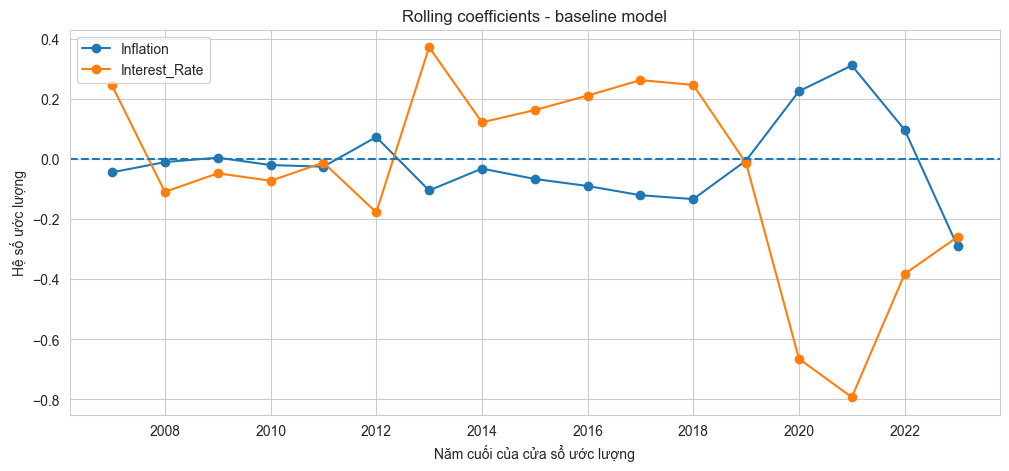

In [9]:

if not rolling_coef.empty:
    cols_to_plot = [c for c in ["Inflation", "Interest_Rate"] if c in rolling_coef.columns]
    plt.figure(figsize=(12, 5))
    for col in cols_to_plot:
        plt.plot(rolling_coef["window_end_year"], rolling_coef[col], marker="o", label=col)
    plt.axhline(0, linestyle="--")
    plt.title("Rolling coefficients - baseline model")
    plt.xlabel("Năm cuối của cửa sổ ước lượng")
    plt.ylabel("Hệ số ước lượng")
    plt.legend()
    plt.show()


## 6. Fitted vs actual với break shading


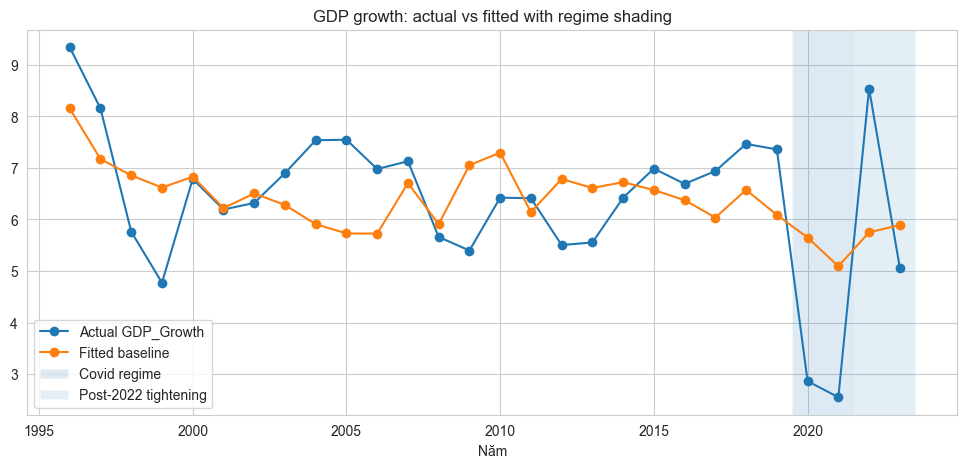

In [10]:

fitted = baseline_res.fittedvalues.reindex(model_df.index)
model_df["fitted_baseline"] = np.nan
model_df.loc[fitted.index, "fitted_baseline"] = fitted.values

plt.figure(figsize=(12, 5))
plt.plot(model_df["Year"], model_df[TARGET], marker="o", label="Actual GDP_Growth")
plt.plot(model_df["Year"], model_df["fitted_baseline"], marker="o", label="Fitted baseline")
plt.axvspan(2020 - 0.5, 2021 + 0.5, alpha=0.15, label="Covid regime")
plt.axvspan(2022 - 0.5, model_df["Year"].max() + 0.5, alpha=0.12, label="Post-2022 tightening")
plt.title("GDP growth: actual vs fitted with regime shading")
plt.xlabel("Năm")
plt.legend()
plt.show()


## 7. Kết luận sẵn sàng dán vào báo cáo


In [11]:

summary_lines = ["### Kết luận gợi ý cho phần structural breaks"]

base_adj_r2 = compare_models.loc[compare_models["model"] == "Baseline HAC OLS", "adj_r2"].iloc[0]
aug_adj_r2 = compare_models.loc[compare_models["model"] == "Augmented HAC OLS with dummies", "adj_r2"].iloc[0]
summary_lines.append(f"- Adjusted R² baseline = {base_adj_r2:.4f}; augmented = {aug_adj_r2:.4f}.")

significant_breaks = chow_df.loc[chow_df["p_value"] < 0.05, "break_year"].tolist()
if significant_breaks:
    summary_lines.append(
        "- Chow test cho thấy break có ý nghĩa tại các mốc: "
        + ", ".join(str(x) for x in significant_breaks)
        + "."
    )
else:
    summary_lines.append("- Chow test chưa cho thấy break đủ mạnh ở các mốc đang kiểm tra.")

if "interest_x_tightening" in augmented_res.params.index:
    p_int = augmented_res.pvalues.get("interest_x_tightening", np.nan)
    coef_int = augmented_res.params.get("interest_x_tightening", np.nan)
    summary_lines.append(
        f"- Interaction `Interest_Rate x tightening_2022plus` = {coef_int:.4f}, p-value = {p_int:.4f}."
    )

summary_lines.append(
    "- Nếu hệ số rolling biến động mạnh, nên diễn giải kết quả theo regime thay vì xem hệ số là ổn định cho toàn bộ giai đoạn."
)

summary_text = "\n".join(summary_lines)
display(Markdown(summary_text))

with open(OUTPUT_DIR / "02_breaks_summary.md", "w", encoding="utf-8") as f:
    f.write(summary_text)


### Kết luận gợi ý cho phần structural breaks
- Adjusted R² baseline = -0.0064; augmented = 0.6533.
- Chow test chưa cho thấy break đủ mạnh ở các mốc đang kiểm tra.
- Interaction `Interest_Rate x tightening_2022plus` = -2.5842, p-value = 0.0000.
- Nếu hệ số rolling biến động mạnh, nên diễn giải kết quả theo regime thay vì xem hệ số là ổn định cho toàn bộ giai đoạn.